# Dementia Detection using Longitudinal MRI Scans

## Setup Dependencies

In [1]:
!nvidia-smi

Thu Feb 20 06:08:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   51C    P0            752W /   60W |       9MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import shutil
from os import path
from typing import LiteralString

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from tf_keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tf_keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tf_keras.losses import SparseCategoricalCrossentropy
from tf_keras.models import Sequential, load_model
from tf_keras.optimizers import Adam
from tf_keras.preprocessing.image import ImageDataGenerator
from tf_keras.utils import image_dataset_from_directory, plot_model

from helper import explain_pred_single_img_lime, explain_pred_incorrect_lime

2025-02-20 06:08:41.570933: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-20 06:08:41.583570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740011921.602095  192303 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740011921.605424  192303 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-20 06:08:41.624935: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [3]:
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

SEED = 42
tf.get_logger().setLevel('ERROR')
tf.random.set_seed(SEED)
np.random.seed(SEED)

2.18.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Download Dataset

In [5]:
!apt-get install aria2
!aria2c -x 16 -s 16 "https://download.nrg.wustl.edu/data/OAS2_RAW_PART1.tar.gz"
!aria2c -x 16 -s 16 "https://download.nrg.wustl.edu/data/OAS2_RAW_PART2.tar.gz"
!aria2c -x 16 -s 16 "https://sites.wustl.edu/oasisbrains/files/2024/03/oasis_longitudinal_demographics-8d83e569fa2e2d30.xlsx"

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?

02/13 05:51:26 [NOTICE] Downloading 1 item(s)
 *** Download Progress Summary as of Thu Feb 13 05:52:26 2025 ***              31m24s]m
[#795c4e 65MiB/10GiB(0%) CN:16 DL:1.1MiB ETA:2h29m40s]
FILE: /home/anikate/PycharmProjects/Dementia Detection using Longitudinal MRI/OAS2_RAW_PART1.tar.gz
-------------------------------------------------------------------------------

 *** Download Progress Summary as of Thu Feb 13 05:53:27 2025 ***              h35m4s]m
[#795c4e 134MiB/10GiB(1%) CN:16 DL:1.0MiB ETA:2h41m23s]
FILE: /home/anikate/PycharmProjects/Dementia Detection using Longitudinal MRI/OAS2_RAW_PART1.tar.gz
-------------------------------------------------------------------------------

 *** Download Progress Summary as of Thu Feb 13 05:54:28 2025 ***              h27m49s]
[#795c4e 199MiB/10GiB(1%) CN:16 DL:1.1Mi

## Extract Dataset

In [4]:
!tar -xvzf OAS2_RAW_PART1.tar.gz
!rm OAS2_RAW_PART1.tar.gz
!tar -xvzf OAS2_RAW_PART2.tar.gz
!rm OAS2_RAW_PART2.tar.gz

!mkdir OAS2_RAW
!mv OAS2_RAW_PART1/* OAS2_RAW/
!mv OAS2_RAW_PART2/* OAS2_RAW/
!rmdir OAS2_RAW_PART1
!rmdir OAS2_RAW_PART2

!mv oasis_longitudinal_demographics-8d83e569fa2e2d30.xlsx demographics.xlsx

OAS2_RAW_PART1/
OAS2_RAW_PART1/OAS2_0001_MR1/
OAS2_RAW_PART1/OAS2_0001_MR1/RAW/
OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-3.nifti.hdr
OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-3.nifti.img
OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-2.nifti.img
OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-2.nifti.hdr
OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-1.nifti.img
OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-1.nifti.hdr
OAS2_RAW_PART1/OAS2_0001_MR2/
OAS2_RAW_PART1/OAS2_0001_MR2/RAW/
OAS2_RAW_PART1/OAS2_0001_MR2/RAW/mpr-1.nifti.hdr
OAS2_RAW_PART1/OAS2_0001_MR2/RAW/mpr-1.nifti.img
OAS2_RAW_PART1/OAS2_0001_MR2/RAW/mpr-2.nifti.hdr
OAS2_RAW_PART1/OAS2_0001_MR2/RAW/mpr-2.nifti.img
OAS2_RAW_PART1/OAS2_0001_MR2/RAW/mpr-3.nifti.hdr
OAS2_RAW_PART1/OAS2_0001_MR2/RAW/mpr-3.nifti.img
OAS2_RAW_PART1/OAS2_0002_MR1/
OAS2_RAW_PART1/OAS2_0002_MR1/RAW/
OAS2_RAW_PART1/OAS2_0002_MR1/RAW/mpr-1.nifti.hdr
OAS2_RAW_PART1/OAS2_0002_MR1/RAW/mpr-1.nifti.img
OAS2_RAW_PART1/OAS2_0002_MR1/RAW/mpr-2.nifti.hdr
OAS2_RAW_PART1/OAS2_0002_MR1/RAW/mpr-2.nifti.img
OAS2_RAW

## Exploratory Data Analysis

In [4]:
PATH_TO_DATASET = "OAS2_RAW"
PATH_TO_DEMOGRAPHICS = "demographics.xlsx"

Visualise the Demographic Data

In [5]:
df = pd.read_excel(PATH_TO_DEMOGRAPHICS)
df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1986.550000,0.696106,0.883440
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004.479526,0.681062,0.875539
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678.290000,0.736336,1.045710
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1737.620000,0.713402,1.010000
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1697.911134,0.701236,1.033623


In [6]:
# Ignore later visits
df = df.loc[df['Visit'] == 1]
df = df.reset_index(drop=True)

df['M/F'] = df['M/F'].map({'M': 1, 'F': 0})
df['Group'] = df['Group'].map({'Converted': 1, 'Demented': 1, 'Nondemented': 0})

df = df.drop(['MRI ID', 'Visit', 'Hand'], axis=1)

# Impute the missing SES values
imputer = SimpleImputer(strategy='median')
df['SES'] = imputer.fit_transform(df[['SES']])

df.head()

,Subject ID,Group,MR Delay,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,0,0,1,87,14,2.0,27.0,0.0,1986.55,0.696106,0.88344
1,OAS2_0002,1,0,1,75,12,2.0,23.0,0.5,1678.29,0.736336,1.04571
2,OAS2_0004,0,0,0,88,18,3.0,28.0,0.0,1215.33,0.709512,1.44406
3,OAS2_0005,0,0,1,80,12,4.0,28.0,0.0,1688.58,0.711502,1.03933
4,OAS2_0007,1,0,1,71,16,2.0,28.0,0.5,1357.33,0.748085,1.29298


In [7]:
# Check for NaN values
df.isnull().sum()

Subject ID    0
Group         0
MR Delay      0
M/F           0
Age           0
EDUC          0
SES           0
MMSE          0
CDR           0
eTIV          0
nWBV          0
ASF           0
dtype: int64

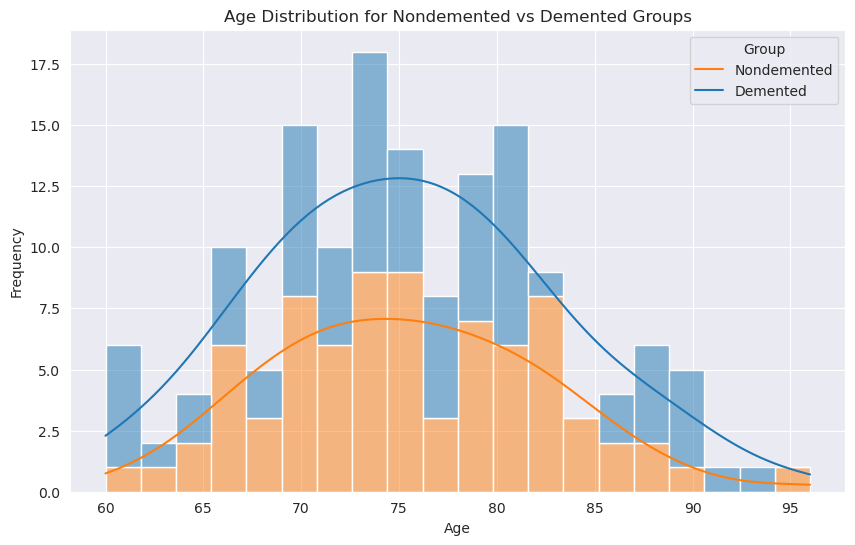

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Group', multiple="stack", bins=20, kde=True, hue_order=[0, 1])
plt.title('Age Distribution for Nondemented vs Demented Groups')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend(title='Group', labels=['Nondemented', 'Demented'])
plt.show()

The histogram above shows the distribution of age for the nondemented and demented groups. The demented group has a higher frequency of older individuals compared to the nondemented group.

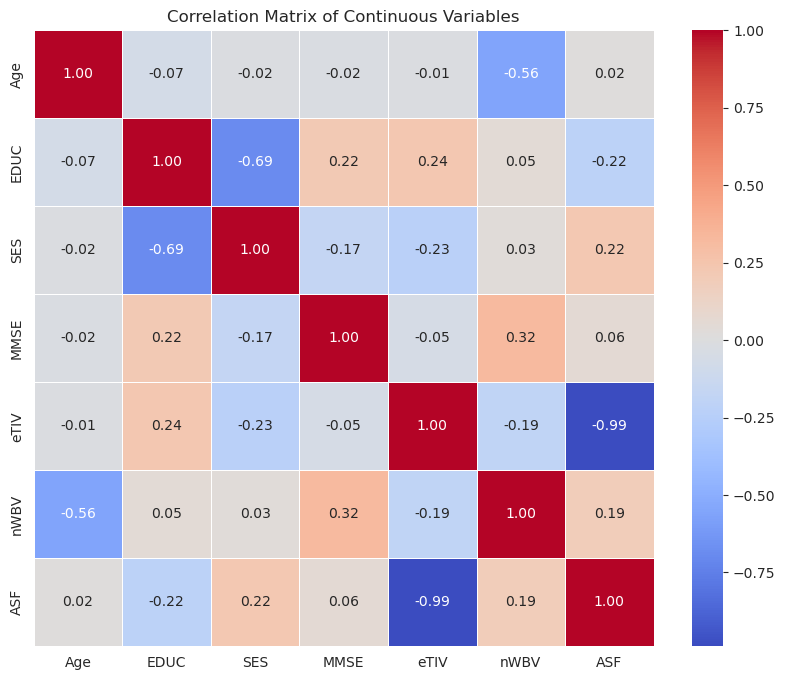

In [9]:
num_cols = ['Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']

# Compute correlation matrix
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Continuous Variables')
plt.show()

The heatmap above shows the correlation matrix of the continuous variables in the dataset. 
1. The **eTIV (Estimated Total Intracranial Volume)** is highly correlated with the **Atlas Scaling Factor (ASF).**
2. The **MMSE (Mini-Mental State Examination) score** is correlated with **nWBV (Normalized Whole Brain Volume)** and **EDUC (Years of Education).**
3. **SES (Socio-Economic Status)** is negatively correlated with **EDUC (Years of Education).**
4. **nWBV (Normalized Whole Brain Volume)** is negatively correlated with **Age.**

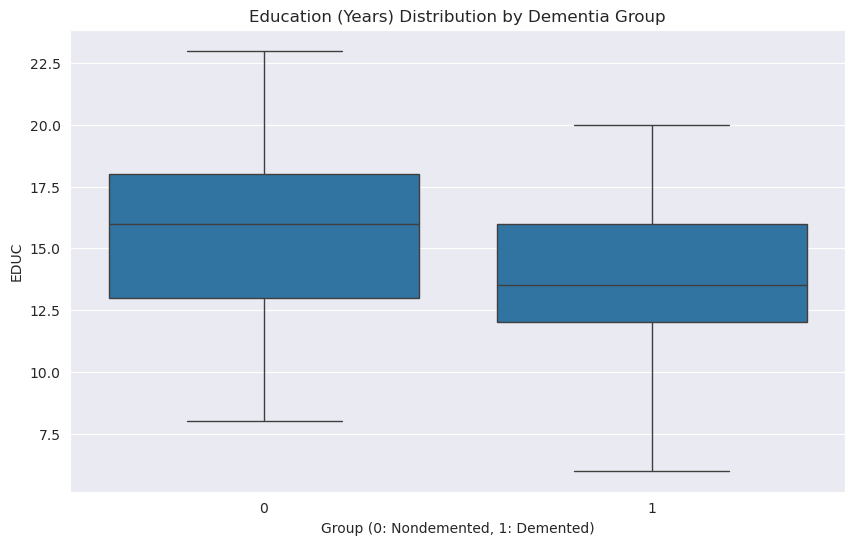

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Group', y='EDUC')
plt.title('Education (Years) Distribution by Dementia Group')
plt.xlabel('Group (0: Nondemented, 1: Demented)')
plt.ylabel('EDUC')
plt.show()

The boxplot above shows that the **distribution of education years is slightly higher for the non-demented group** compared to the demented group.

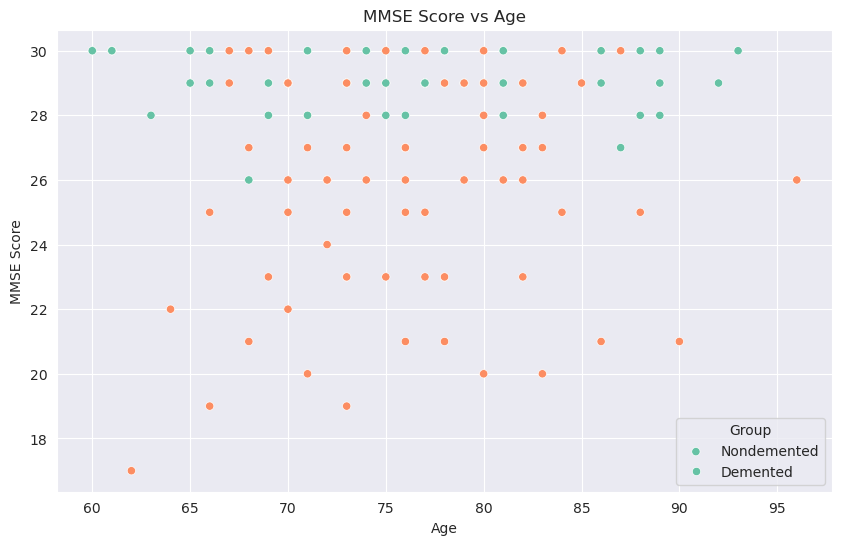

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='MMSE', hue='Group', palette='Set2')
plt.title('MMSE Score vs Age')
plt.xlabel('Age')
plt.ylabel('MMSE Score')
plt.legend(title='Group', labels=['Nondemented', 'Demented'])
plt.show()

The scatter plot above shows that the **MMSE scores decrease with age for both the demented and nondemented groups.**

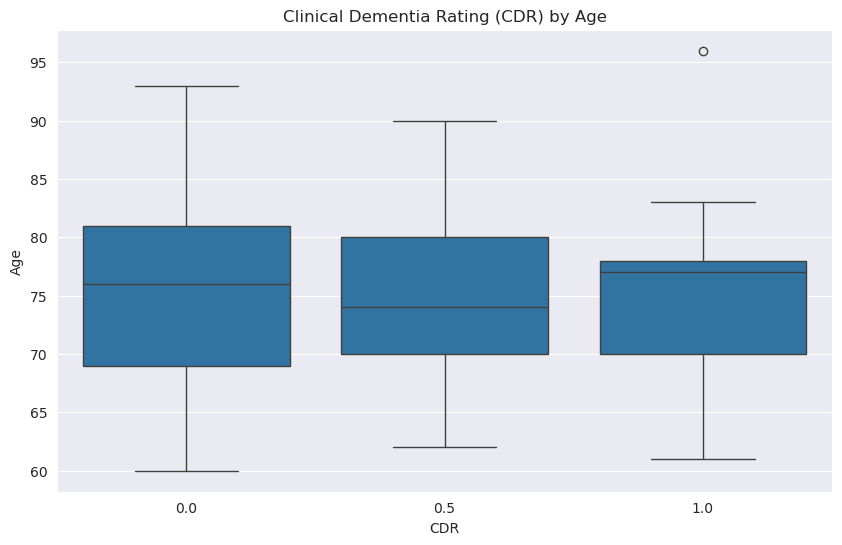

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='CDR', y='Age')
plt.title('Clinical Dementia Rating (CDR) by Age')
plt.xlabel('CDR')
plt.ylabel('Age')
plt.show()

The boxplot above shows that the **Clinical Dementia Rating (CDR) increases with age.**

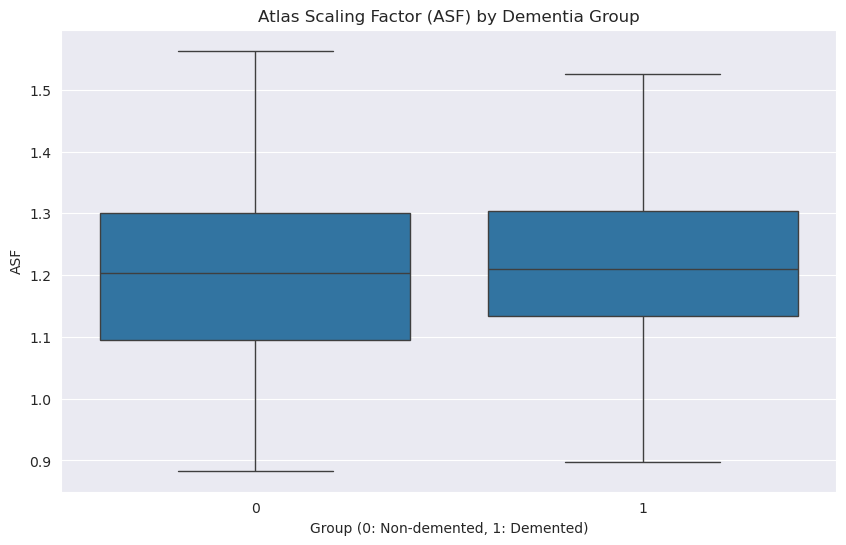

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Group', y='ASF')
plt.title('Atlas Scaling Factor (ASF) by Dementia Group')
plt.xlabel('Group (0: Non-demented, 1: Demented)')
plt.ylabel('ASF')
plt.show()

The boxplot above shows that the **Atlas Scaling Factor (ASF) is slightly higher for the demented group** compared to the nondemented group.

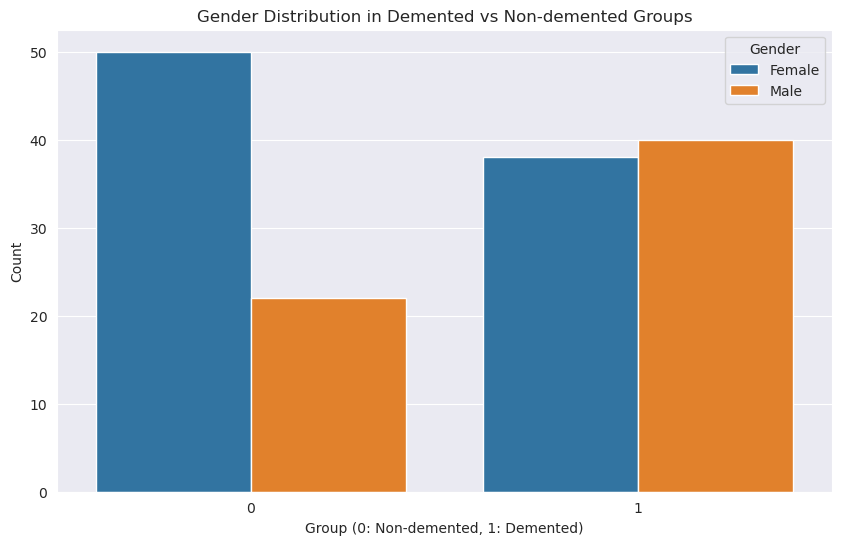

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Group', hue='M/F', hue_order=[0, 1])
plt.title('Gender Distribution in Demented vs Non-demented Groups')
plt.xlabel('Group (0: Non-demented, 1: Demented)')
plt.ylabel('Count')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.show()

The count plot above shows that **Dementia is more prevalent in Males.**

Summary of Visual EDA:
- The eTIV (Estimated Total Intracranial Volume) is highly correlated with the Atlas Scaling Factor (ASF).
- The MMSE (Mini-Mental State Examination) score is correlated with nWBV (Normalized Whole Brain Volume) and EDUC (Years of Education).
- SES (Socio-Economic Status) is negatively correlated with EDUC (Years of Education).
- nWBV (Normalized Whole Brain Volume) is negatively correlated with Age.
- The distribution of education years is slightly higher for the non-demented group compared to the demented group.
- The MMSE scores decrease with age for both the demented and nondemented groups.
- The Clinical Dementia Rating (CDR) increases with age.
- The Atlas Scaling Factor (ASF) is slightly higher for the demented group compared to the nondemented group.
- Dementia is more prevalent in Males.

In [5]:
CDR_MAP = {
    0.0: 'Non-Demented',
    0.5: 'Mildly Demented',
    1.0: 'Demented'
}

## Visualise MRI Scans

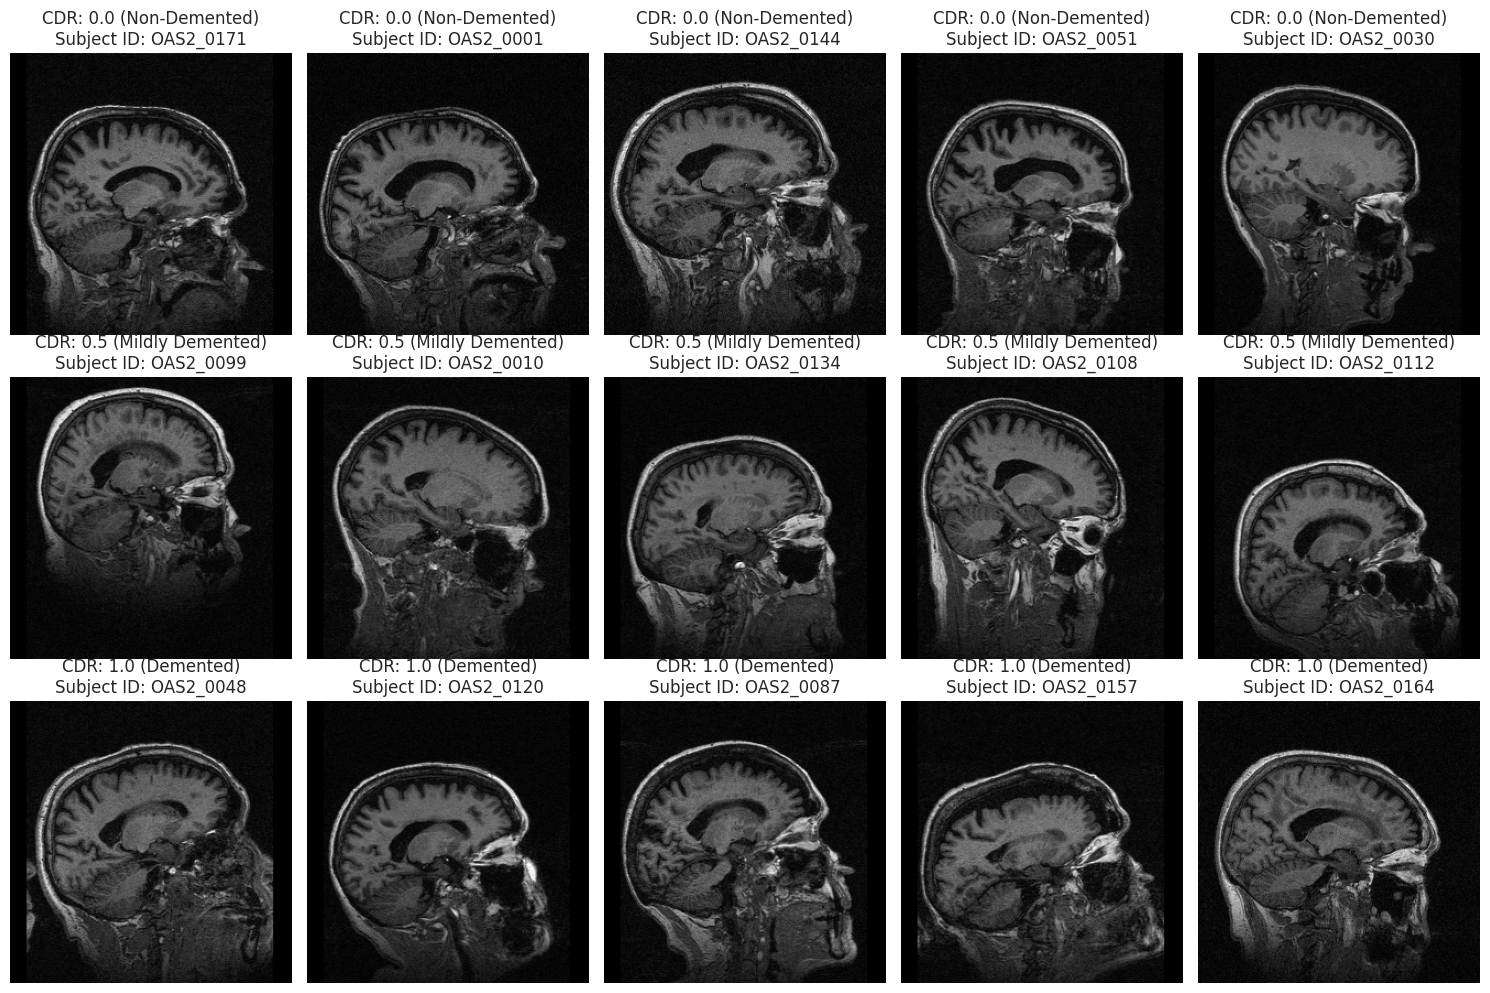

In [17]:
# Get 5 random subjects for each CDR category and display their MRI scans
random_cdr_subjects = {}
for cdr, group in CDR_MAP.items():
    random_cdr_subjects[cdr] = df[df['CDR'] == cdr].sample(5)['Subject ID'].values

hdr_files = {cdr: [path.join(subId + '_MR1', 'RAW', 'mpr-1.nifti.hdr') for subId in ids] for cdr, ids in
             random_cdr_subjects.items()}

fig, axes = plt.subplots(3, 5, figsize=(15, 10))

for i, (cdr, files) in enumerate(hdr_files.items()):
    for j, file in enumerate(files):
        img = nib.load(path.join(PATH_TO_DATASET, file)).get_fdata()
        img = np.rot90(img)

        axes[i, j].imshow(img[:, :, 50], cmap='gray')
        axes[i, j].set_title(f'CDR: {cdr} ({CDR_MAP[cdr]})\nSubject ID: {random_cdr_subjects[cdr][j]}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

## Data Organisation

In [18]:
# Create 3 directories for each CDR category
for cdr, group in CDR_MAP.items():
    os.makedirs(path.join(PATH_TO_DATASET, group), exist_ok=True)

file_mvmnt = {
    0.0: 0,
    0.5: 0,
    1.0: 0
}

# Iterate over each subfolder in the dataset that begins with 'OAS'
for subfolder in os.listdir(PATH_TO_DATASET):
    if not subfolder.startswith('OAS'):
        continue

    raw_folder = os.path.join(PATH_TO_DATASET, subfolder, 'RAW')

    # Load each .hdr file in the RAW folder
    for file in os.listdir(raw_folder):
        if file.endswith('.hdr'):
            hdr_path = os.path.join(raw_folder, file)
            img = nib.load(hdr_path)

            # Extract Subject ID and create the new filename
            subject_id = subfolder[:9]
            new_filename = f"{subfolder}_{file.split('.')[0].replace("-", "")}.nii"

            # Determine the CDR category directory
            cdr_value = df.loc[df['Subject ID'] == subject_id, 'CDR'].values[0]
            cdr_category = CDR_MAP[cdr_value]
            save_path = os.path.join(PATH_TO_DATASET, cdr_category, new_filename)

            # Save the file as .nii in the corresponding CDR category directory
            nib.save(img, save_path)
            file_mvmnt[cdr_value] += 1

            # Remove the .hdr and .img files
            os.remove(hdr_path)
            if os.path.exists(hdr_path.replace('.hdr', '.img')):
                os.remove(hdr_path.replace('.hdr', '.img'))

    # Remove the subfolder
    shutil.rmtree(os.path.join(PATH_TO_DATASET, subfolder))

for cdr in CDR_MAP.keys():
    print(f"{CDR_MAP[cdr]} files saved: {file_mvmnt[cdr]}")

Non-Demented files saved: 820
Mildly Demented files saved: 429
Demented files saved: 119


In [19]:
def convert_nii_to_jpg_slices(nii_file_path: str | LiteralString | bytes,
                              slice_indices: tuple[int] = (25, 40, 60, 70, 90, 120),
                              plot_slices=False):
    """
    Converts a .nii file to a series of .jpg images representing the slices of the 3D volume.
    
    :param nii_file_path: Full path to the .nii file
    :param slice_indices: Tuple of slice indices to extract
    :param plot_slices: Whether to plot the slices for visualization
    :return: 
    """

    nii = nib.load(nii_file_path)
    nii_data = nii.get_fdata()

    # Transpose the data for visualization
    nii_data = np.transpose(nii_data, (1, 0, 2, 3))

    axis = None
    if plot_slices:
        fig, axis = plt.subplots(1, len(slice_indices), figsize=(3 * len(slice_indices), 3))

    # Plot each slice
    for i, slice in enumerate(slice_indices):
        slice_data = nii_data[:, :, slice, 0]

        slice_filename = nii_file_path.replace('.nii', f'_s{slice}.jpg')
        plt.imsave(slice_filename, slice_data, cmap='gray')

        if plot_slices:
            axis[i].imshow(slice_data, cmap='gray', origin='lower')
            axis[i].set_title(f'Slice {slice}')
            axis[i].axis('off')

    if plot_slices:
        plt.tight_layout()
        plt.show()

Pick the slice images from the MRI scans

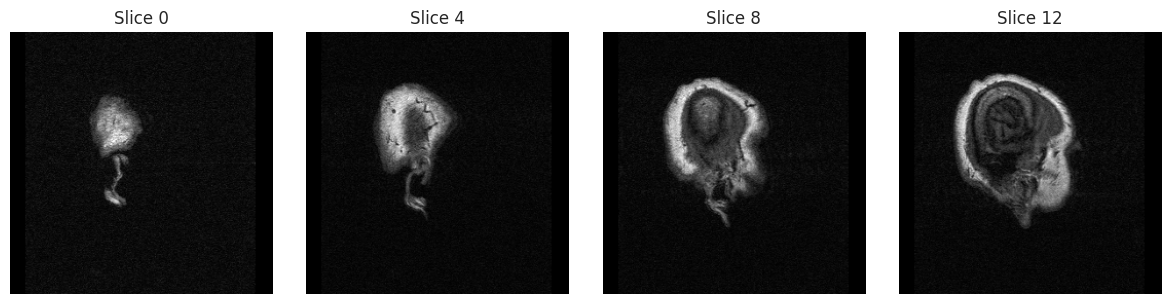

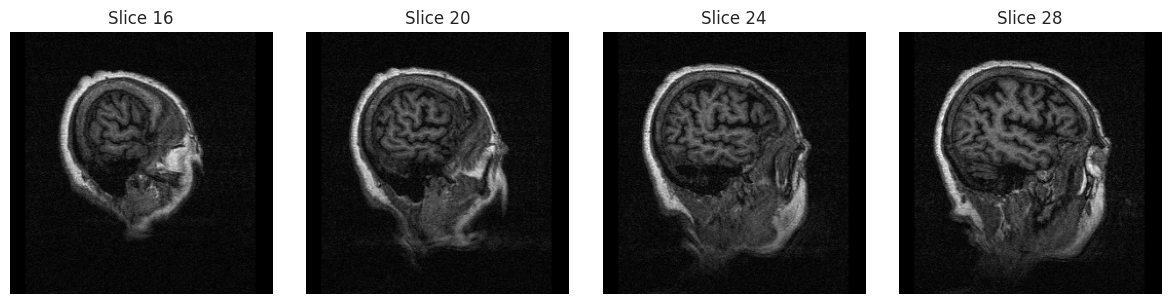

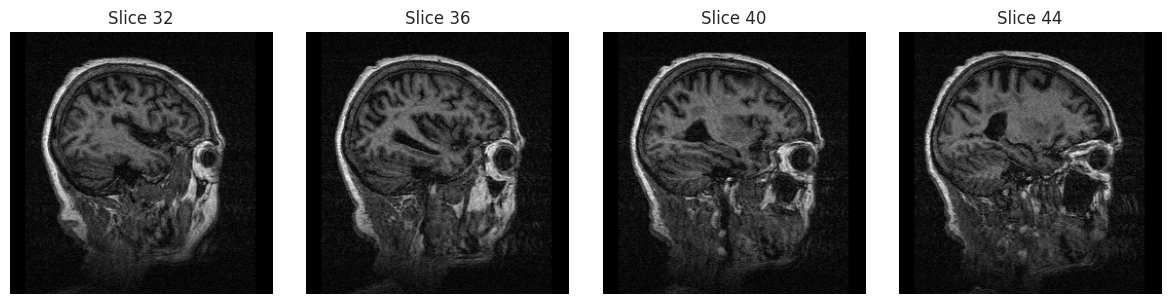

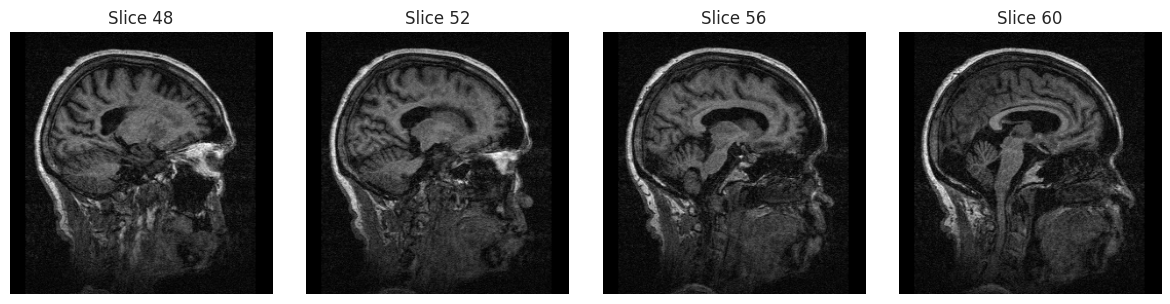

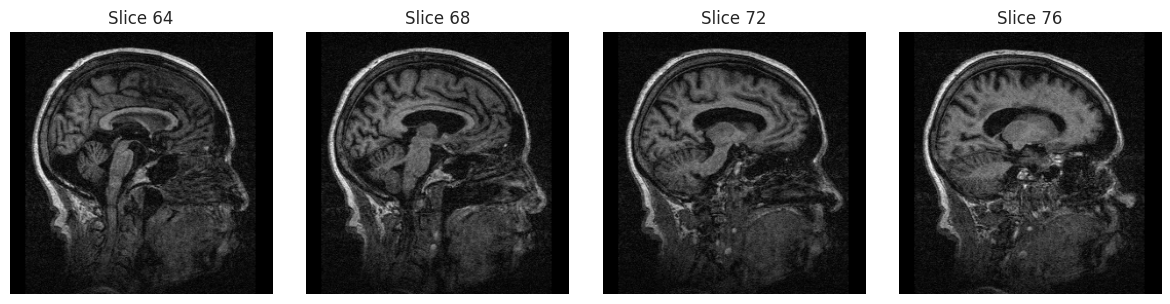

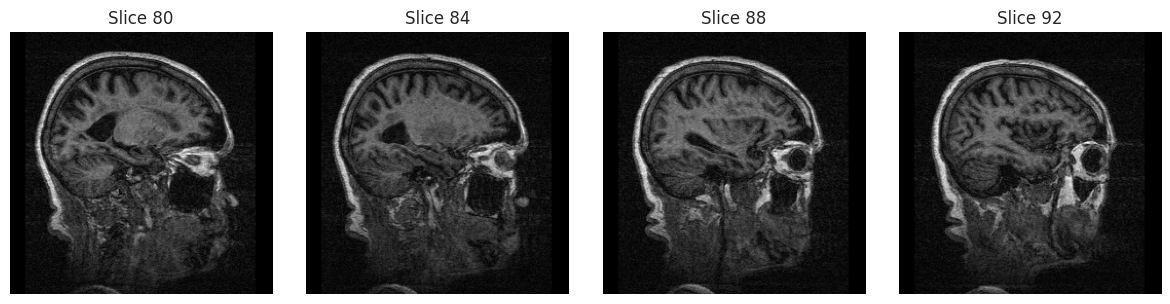

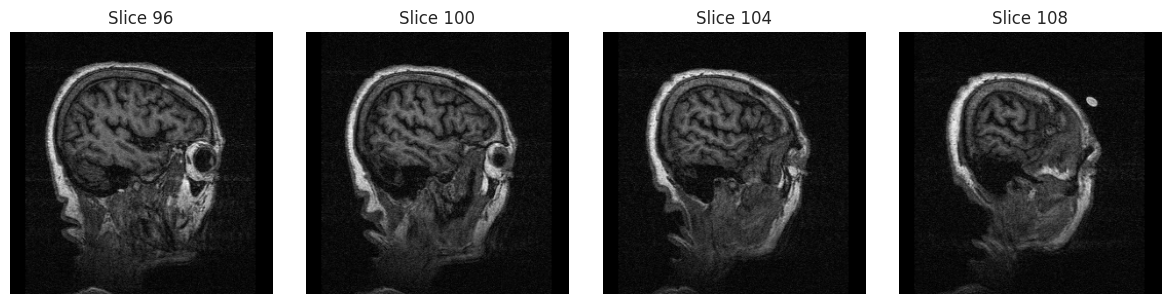

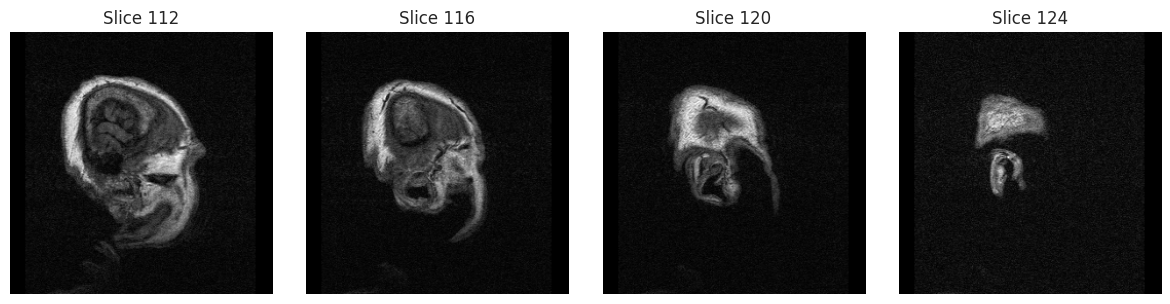

In [20]:
example_nii_path = path.join(PATH_TO_DATASET, 'Demented', os.listdir(path.join(PATH_TO_DATASET, 'Demented'))[2])
for i in range(0, 32, 4):
    convert_nii_to_jpg_slices(example_nii_path, plot_slices=True,
                              slice_indices=(4 * i, 4 * (i + 1), 4 * (i + 2), 4 * (i + 3)))

From the above image, the following slices are of the most interest: 28, 32, 40, 48, 56, 68, 72, 76, 80, 84, 92, 104

In [21]:
SLICE_INDICES = (28, 32, 40, 48, 56, 68, 72, 76, 80, 84, 92, 104)

In [22]:
for folder in os.listdir(PATH_TO_DATASET):
    folder_path = os.path.join(PATH_TO_DATASET, folder)
    for file in os.listdir(folder_path):
        if file.endswith('.nii'):
            convert_nii_to_jpg_slices(os.path.join(folder_path, file), slice_indices=SLICE_INDICES)
            os.remove(os.path.join(folder_path, file))

## Data Pre-processing

Non-Demented: 9840
Mildly Demented: 5148
Demented: 1448


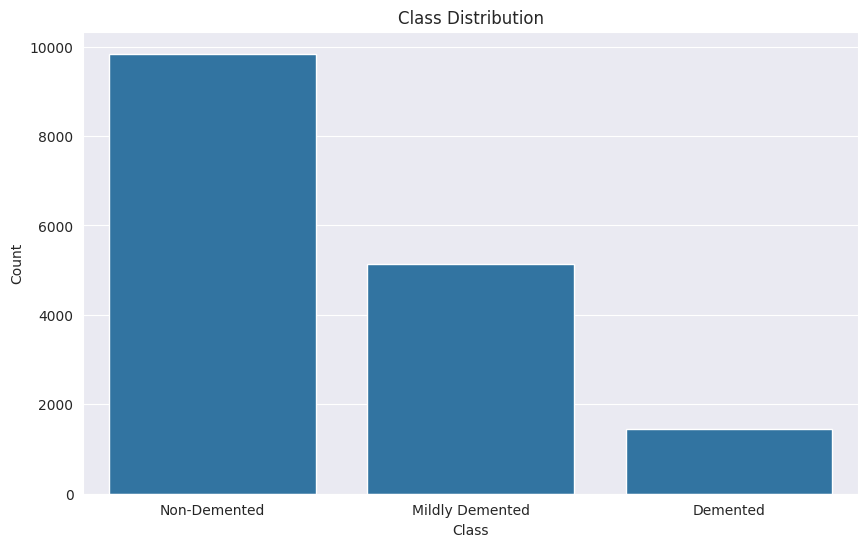

In [29]:
class_counts = {group: len(os.listdir(os.path.join(PATH_TO_DATASET, group))) for group in CDR_MAP.values()}
for group, count in class_counts.items():
    print(f"{group}: {count}")

plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [7]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
TARGET_COUNT = max(class_counts.values())

In [8]:
categories = list(class_counts.keys())

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

for category in categories:
    category_dir = os.path.join(PATH_TO_DATASET, category)
    images = os.listdir(category_dir)
    num_images = len(images)

    # Check if the category needs augmentation
    if num_images < TARGET_COUNT:
        augment_count = TARGET_COUNT - num_images
        print(f'Augmenting {augment_count} images, for category: {category}.')
        augment_iter = datagen.flow_from_directory(
            PATH_TO_DATASET,
            target_size=IMG_SIZE,
            classes=[category],
            batch_size=1,
            seed=SEED,
            class_mode=None,
            shuffle=True,
            save_to_dir=category_dir,
            save_prefix='aug_',
            save_format='jpg'
        )

        # Generate and save additional images
        for i in range(augment_count):
            augment_batch = next(augment_iter)

Non-Demented: 9840
Mildly Demented: 9840
Demented: 9840


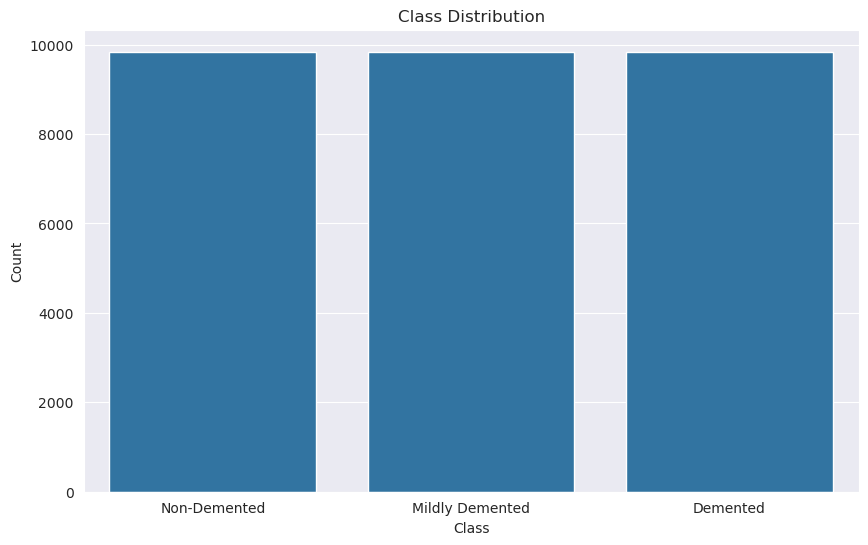

In [6]:
class_counts = {group: len(os.listdir(os.path.join(PATH_TO_DATASET, group))) for group in CDR_MAP.values()}
for group, count in class_counts.items():
    print(f"{group}: {count}")

plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [9]:
data = image_dataset_from_directory(
    PATH_TO_DATASET,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
    color_mode='grayscale'
)

class_names = data.class_names

Found 29520 files belonging to 3 classes.


I0000 00:00:1740011955.393074  192303 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2278 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
def train_test_val_split(data, train_size, val_size, test_size):
    train = int(len(data) * train_size)
    val = int(len(data) * val_size)
    test = int(len(data) * test_size)

    train_data = data.take(train)
    val_data = data.skip(train).take(val)
    test_data = data.skip(train + val).take(test)

    return train_data, val_data, test_data


train_data, val_data, test_data = train_test_val_split(data, train_size=0.8, val_size=0.1, test_size=0.1)

In [11]:
def normalize_images(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

In [12]:
# Apply normalization to datasets
train_data = train_data.map(normalize_images)
val_data = val_data.map(normalize_images)
test_data = test_data.map(normalize_images)

# Prefetch and cache the datasets for better performance
train_data = train_data.prefetch(tf.data.experimental.AUTOTUNE)
val_data = val_data.prefetch(tf.data.experimental.AUTOTUNE)
test_data = test_data.prefetch(tf.data.experimental.AUTOTUNE)

## Plot Sample Images pre-Training

2025-02-20 05:28:28.550878: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


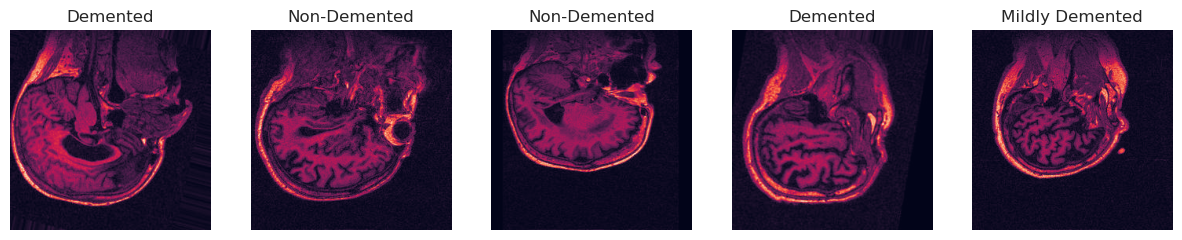

In [13]:
def plot_sample_images(class_names):
    for images, labels in train_data.take(1):
        sample_images = images[:5]
        sample_labels = labels[:5]

    # Plot the images with their categories
    plt.figure(figsize=(15, 10))
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(sample_images[i])
        plt.title(class_names[sample_labels[i]])
        plt.axis("off")
    plt.show()


plot_sample_images(class_names)

## Model Architecture

In [26]:
# Define the CNN architecture
model = Sequential([
    Input(shape=(256, 256, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    # Lambda(lambda x: tf.reshape(x, (-1, x.shape[1] // 16, 16))),
    # LSTM(64, return_sequences=False),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

In [27]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [28]:
if not os.path.exists('model_checkpoints'):
    os.makedirs('model_checkpoints')

In [29]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

learning_rate_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

model_checkpoint = ModelCheckpoint(
    filepath='model_checkpoints/best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

In [30]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 254, 254, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 128)      

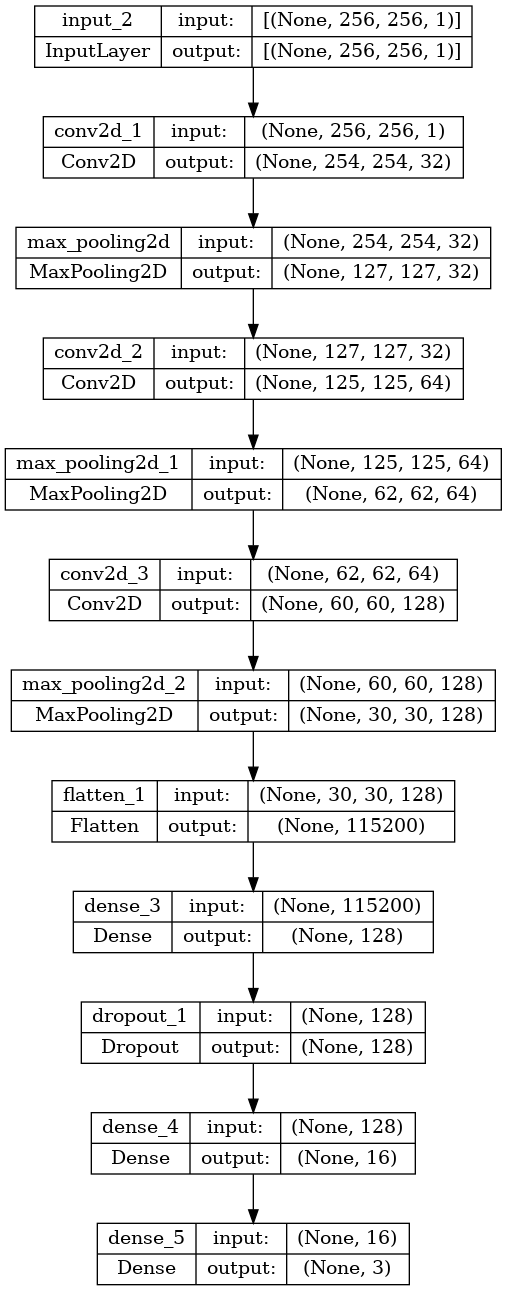

In [31]:
plot_model(model, show_shapes=True)

## Fit the Model

In [32]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[
        early_stopping,
        learning_rate_scheduler,
        model_checkpoint
    ]
)

Epoch 1/30


I0000 00:00:1740004453.895321    6095 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1740004454.700135    6094 service.cc:148] XLA service 0x7e01d078be00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1740004454.700323    6094 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-02-20 04:04:14.706801: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-02-20 04:04:14.729517: W external/local_xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.5.82. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.
I0000 0

2952/2952 [==============================] - 67s 22ms/step - loss: 0.8016 - accuracy: 0.6087 - val_loss: 0.6462 - val_accuracy: 0.6795 - lr: 1.0000e-04
Epoch 2/30


/home/anikate/miniconda3/envs/tf2/lib/python3.12/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2952/2952 [==============================] - 64s 22ms/step - loss: 0.6039 - accuracy: 0.7182 - val_loss: 0.4845 - val_accuracy: 0.7879 - lr: 1.0000e-04
Epoch 3/30
2952/2952 [==============================] - 64s 22ms/step - loss: 0.4680 - accuracy: 0.7887 - val_loss: 0.3784 - val_accuracy: 0.8350 - lr: 1.0000e-04
Epoch 4/30
2952/2952 [==============================] - 64s 22ms/step - loss: 0.3668 - accuracy: 0.8384 - val_loss: 0.3397 - val_accuracy: 0.8432 - lr: 1.0000e-04
Epoch 5/30
2952/2952 [==============================] - 65s 22ms/step - loss: 0.3067 - accuracy: 0.8680 - val_loss: 0.2868 - val_accuracy: 0.8730 - lr: 1.0000e-04
Epoch 6/30
2952/2952 [==============================] - 66s 22ms/step - loss: 0.2500 - accuracy: 0.8922 - val_loss: 0.2599 - val_accuracy: 0.8892 - lr: 1.0000e-04
Epoch 7/30
2952/2952 [==============================] - 66s 22ms/step - loss: 0.2105 - accuracy: 0.9103 - val_loss: 0.2360 - val_accuracy: 0.8984 - lr: 1.0000e-04
Epoch 8/30
2952/2952 [===========

## Plot History

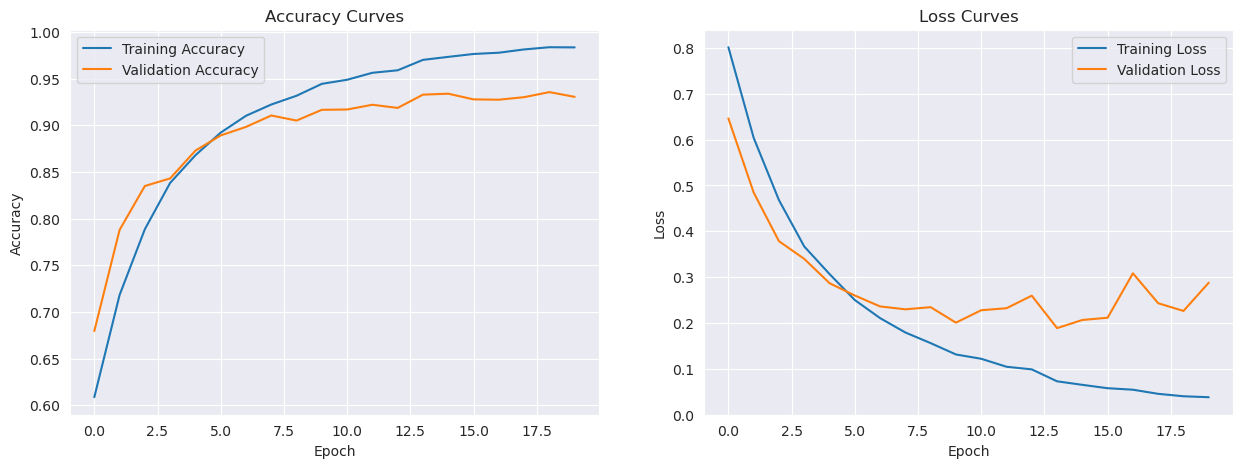

In [33]:
# Plot accuracy and loss curves side by side
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

plt.show()

## Evaluate the Model

In [13]:
model = load_model('model_checkpoints/best_model.h5')

In [14]:
model.evaluate(test_data)

I0000 00:00:1740011968.717753  192473 cuda_dnn.cc:529] Loaded cuDNN version 90300


369/369 [==============================] - 5s 7ms/step - loss: 0.2107 - accuracy: 0.9278


[0.2107209414243698, 0.9278455376625061]

Classification Report:
                 precision    recall  f1-score   support

       Demented       0.87      0.94      0.90       978
Mildly Demented       0.92      0.86      0.89       948
   Non-Demented       1.00      0.99      1.00      1026

       accuracy                           0.93      2952
      macro avg       0.93      0.93      0.93      2952
   weighted avg       0.93      0.93      0.93      2952



2025-02-20 06:09:48.154268: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


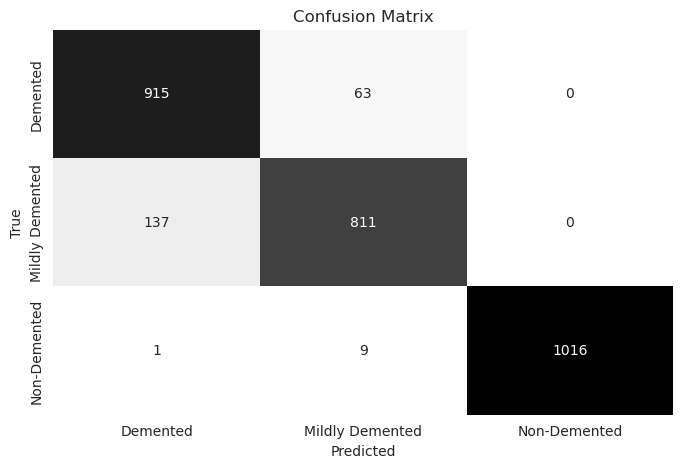

In [15]:
def report(model, test_data, class_names):
    # Generate predictions
    predictions = []
    labels = []
    for X, y in test_data.as_numpy_iterator():
        y_pred = model.predict(X, verbose=0)
        y_prediction = np.argmax(y_pred, axis=1)
        predictions.extend(y_prediction)
        labels.extend(y)

    predictions = np.array(predictions)
    labels = np.array(labels)

    # Generate classification report
    print("Classification Report:")
    print(classification_report(labels, predictions, target_names=class_names))

    # Generate confusion matrix
    cm = confusion_matrix(labels, predictions)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    # Plot confusion matrix
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greys", cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


report(model, test_data, class_names)

1/1 [==============================] - 0s 13ms/step


2025-02-20 06:09:51.226082: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 [==============================] - 0s 13ms/step


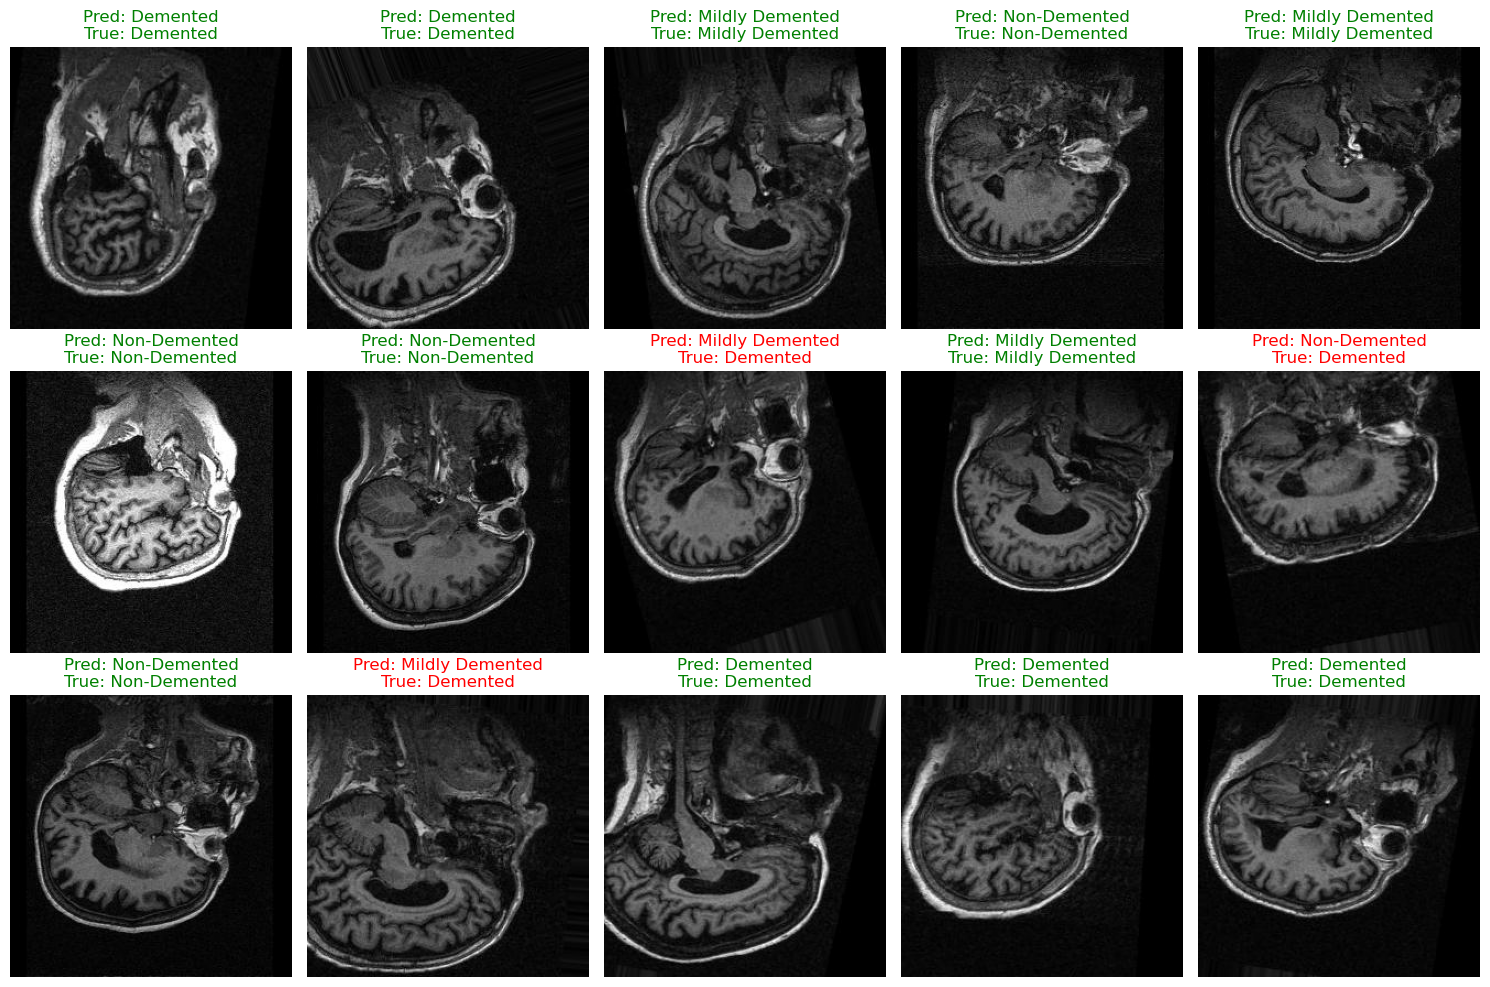

In [16]:
import matplotlib.pyplot as plt
import numpy as np


def plot_predictions(test_data, model, class_names):
    plt.figure(figsize=(15, 10))
    count = 0

    while True:
        for images, labels in test_data.take(1):
            # Denormalize images
            images = images * 255.0

            predictions = model.predict(images)
            predicted_labels = np.argmax(predictions, axis=1)

            for i in range(len(images)):
                plt.subplot(3, 5, count + 1)
                plt.imshow(images[i].numpy().astype("uint8"), cmap='gray')
                color = "green" if predicted_labels[i] == labels[i] else "red"
                plt.title(f"Pred: {class_names[predicted_labels[i]]}\nTrue: {class_names[labels[i]]}", color=color)
                plt.axis("off")
                count += 1
                if count == 15:
                    break

            if count == 15:
                break

        if count == 15:
            break

    plt.tight_layout()
    plt.show()


plot_predictions(test_data, model, class_names)

In [17]:
# Numpy Arrays to store test images and labels
test_imgs = np.array([])
test_lbls = np.array([])

count = 0
for X, y in test_data.as_numpy_iterator():
    test_imgs = np.append(test_imgs, X)
    test_lbls = np.append(test_lbls, y)
    count += 1
    if count == 100:
        break

  0%|          | 0/10000 [00:00<?, ?it/s]

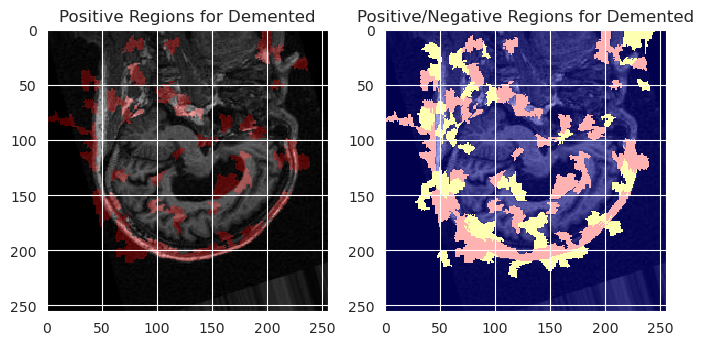

In [43]:
explain_pred_single_img_lime(
    model=model,
    test_imgs=test_imgs,
    test_lbls=test_lbls,
    class_names=class_names,
    img_shape=(256, 256),
    index=7,
    num_samples=10000,
    num_features=10000000000
)

Using #728 where the label was Mildly Demented and the model predicted Demented


  0%|          | 0/1000 [00:00<?, ?it/s]

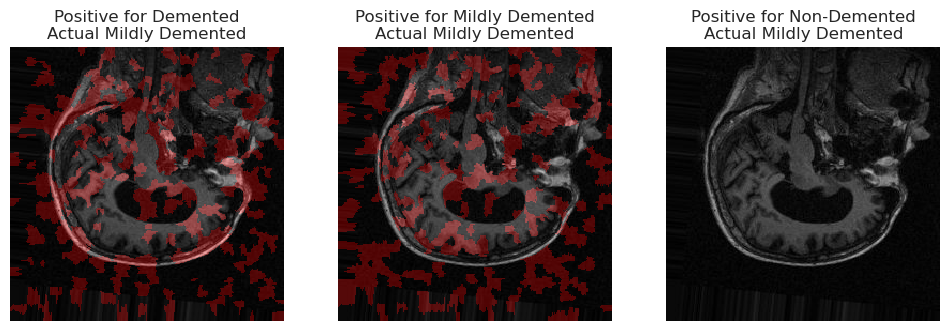

In [44]:
explain_pred_incorrect_lime(
    model=model,
    test_imgs=test_imgs,
    test_lbls=test_lbls,
    class_names=class_names,
    img_shape=(256, 256),
    num_samples=1000,
    num_features=1000000
)